# Imports

In [1]:
# imports
import numpy as np
import warnings
import os

import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p/"src").is_dir())))

# Robust import to avoid name collisions / env errors
from rfphate import RFPHATE
from rfgap import RFGAP
from phate import PHATE
from umap import UMAP


# Alignment models
from src.mali import MALI
from src.frost import FROST



from src.kema import KEMA
from src.jpamona import JPamona


from utils.tree_utils import gen_tree

from phate import PHATE # We need the base PHATE class for the final step
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox # For image plotting
from scipy import sparse
import seaborn as sns

from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Evaluation metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score



# Silence harmless warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


/Users/aumona/Projects/RF-MALI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Generate two artifical with 10 branches (fully labeled): source tree is clean, target has additional 1000 uniform (0,1) noise features.

In [2]:
model_name = "FROST"
embedder = "PHATE"

mu = 0.5  # Intra-domain structure preservation strength
gamma = 0.5  # For JPamona only (supervision strength for OT)
seed = 42


n_noise = 500  # number of noise features to append to SOURCE domain
frac_labeled = 0.5   # %labeled in TARGET domain (for semi-supervised methods)
remove_p_target = 0.5  # e.g. 0.2 removes 20% of TARGET samples



seed_source = 32  # 322
seed_target = 42  # 42
x_source, y_source, _ = gen_tree(n_branch=10, n_child = 2, n_dim_per_branch = 4, branch_length=1000, seed=seed_source, sigma=7, merged_branch = False)
x_target, y_target, _ = gen_tree(n_branch=10, n_child = 2, n_dim_per_branch = 6, branch_length=1000, seed=seed_target, sigma=7, merged_branch = False)
x_source, x_target = MinMaxScaler().fit_transform(x_source), MinMaxScaler().fit_transform(x_target)  # Normalize
T_true = np.eye(len(x_source))  # True OT matrix (identity bc aligned)


# append uniform(0,1) noise features to x_source
rng = np.random.RandomState(42)
noise_feats = rng.rand(x_source.shape[0], n_noise)
x_source = np.hstack([noise_feats, x_source])
print(f"Source shape: {x_source.shape}, Target shape: {x_target.shape}")



# add nans  to y_target for smei-supervised setting
# ---------------------------------------------------------
# Stratified masking: ~10% unlabeled, at least 1 per class
# ---------------------------------------------------------
if frac_labeled >= 1.0:
    print("Using all labels, skipping stratified masking.")
    y_target = np.asarray(y_target)
else:
    y_target = np.asarray(y_target).copy()

    sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=frac_labeled,
        random_state=seed
    )

    # sss.split yields (labeled_idx, unlabeled_idx)
    labeled_idx, unlabeled_idx = next(sss.split(np.zeros(len(y_target)), y_target))

    # Mark unlabeled as -1
    y_target[unlabeled_idx] = -1

    # --- Sanity check ---
    assert set(np.unique(y_target[y_target != -1])) == set(np.unique(y_target[y_target != -1])), \
        "A class disappeared after stratified masking"

    print(f"Masked {len(unlabeled_idx)} / {len(y_target)} labels ({len(unlabeled_idx)/len(y_target):.1%})")

# ---------------------------------------------------------
# Option: randomly REMOVE p% of target (domain B) samples
# ---------------------------------------------------------
rng_remove = np.random.RandomState(seed)

if remove_p_target > 0:
    y_target = np.asarray(y_target).ravel()
    nB = len(y_target)
    n_keep = int(np.round((1.0 - remove_p_target) * nB))
    n_keep = max(1, min(n_keep, nB))  # keep at least 1, at most nB

    keep_idx = rng_remove.choice(nB, size=n_keep, replace=False)
    keep_idx = np.sort(keep_idx)      # preserves original order

    x_target = x_target[keep_idx]
    y_target = y_target[keep_idx]

    print(f"Removed {nB - n_keep}/{nB} target samples ({remove_p_target:.1%}). New target size: {n_keep}")


Source shape: (10000, 540), Target shape: (10000, 60)
Masked 5000 / 10000 labels (50.0%)
Removed 5000/10000 target samples (50.0%). New target size: 5000


# Model training and alignment

In [ ]:
# ------------------------------------
# MODEL TRAINING & ALIGNMENT
# ------------------------------------
if model_name == "FROST":
    model = FROST(
        embedder=embedder,
        dpt=False,
        n_landmark=2000,
        dist='cosine',
        n_components=2,
        random_state=seed,
        mu=mu,
        n_jobs=-1,
        verbose=1
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'MALI':
    model = MALI(embedder=embedder,
                 n_components=2,
                 m=1,
                 random_state=seed)
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'KEMA':
    model = KEMA(
        n_components=2,
        kernel='linear',
        mu=mu
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")
elif model_name == 'JPamona':
    model = JPamona(
        n_components=2,
        embedder=embedder,
        mu=mu,
        gamma=gamma,  # controls supervision strength, 1=fully supervised
        random_state=seed
    )
    print("\nStarting alignment...")
    %time embedding = model.fit_transform(x_source, x_target, y_source, y_target)
    print("Alignment complete.")

# project barycentric embeddings in 2D using UMAP
if embedder == 'barycentric':
    umap = UMAP(n_components=2, random_state=seed)
    embedding = umap.fit_transform(embedding)
print(embedding.shape)



Starting alignment...
Fitting RFGAP on Domain A...
Fitting RFGAP on Domain B...
Semi-supervised mode. Forcing `non_zero_diagonal`=True and `force_symmetric`=True for consistency.
Building C-dim vectors...
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 2.20 seconds.
  Calculating KMeans...
  Calculated KMeans in 2.52 seconds.
Calculated landmark operator in 4.72 seconds.
Using LandmarkGraph operators (N→M and M→M).
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 0.92 seconds.
  Calculating KMeans...
  Calculated KMeans in 1.57 seconds.
Calculated landmark operator in 2.49 seconds.
Using LandmarkGraph operators (N→M and M→M).
Computing Optimal Transport...
Optimized rank-annealing schedule: [5, 1000]
[WARN] MiniBatchKMeans produced 414/5000 empty clusters during compression.

SPARSE COUPLING
---------------
Empty rows: 2193 / 10000
Empty cols: 1328 / 5000
Total mass: 4596.0
Building joint affinity matrix...
Model fit complete.
Computi

# Visualize joint affinity matrix

In [4]:

# prox_mat = model.W.toarray() if model_name == "RFMALI" else model.W


# # mask diagonal to emphasize off-diagonal proximities
# mask=None

# fig, ax = plt.subplots(figsize=(10, 10))
# sns.heatmap(prox_mat, ax=ax, cmap='rocket_r', vmin=0, vmax=prox_mat.max(),
#             mask=mask,
#             xticklabels=False, yticklabels=False, square=True, cbar_kws={'label': 'Proximity'})
# ax.set_title(f'Joint Affinity Matrix')
# plt.show()

# Plot


--- Visualization ---
Data Check: Source=10000, Target=5000 | Embedding shape=(15000, 2)
  Adjusting T_true columns using keep_idx...
  Plotted 50 matching lines.


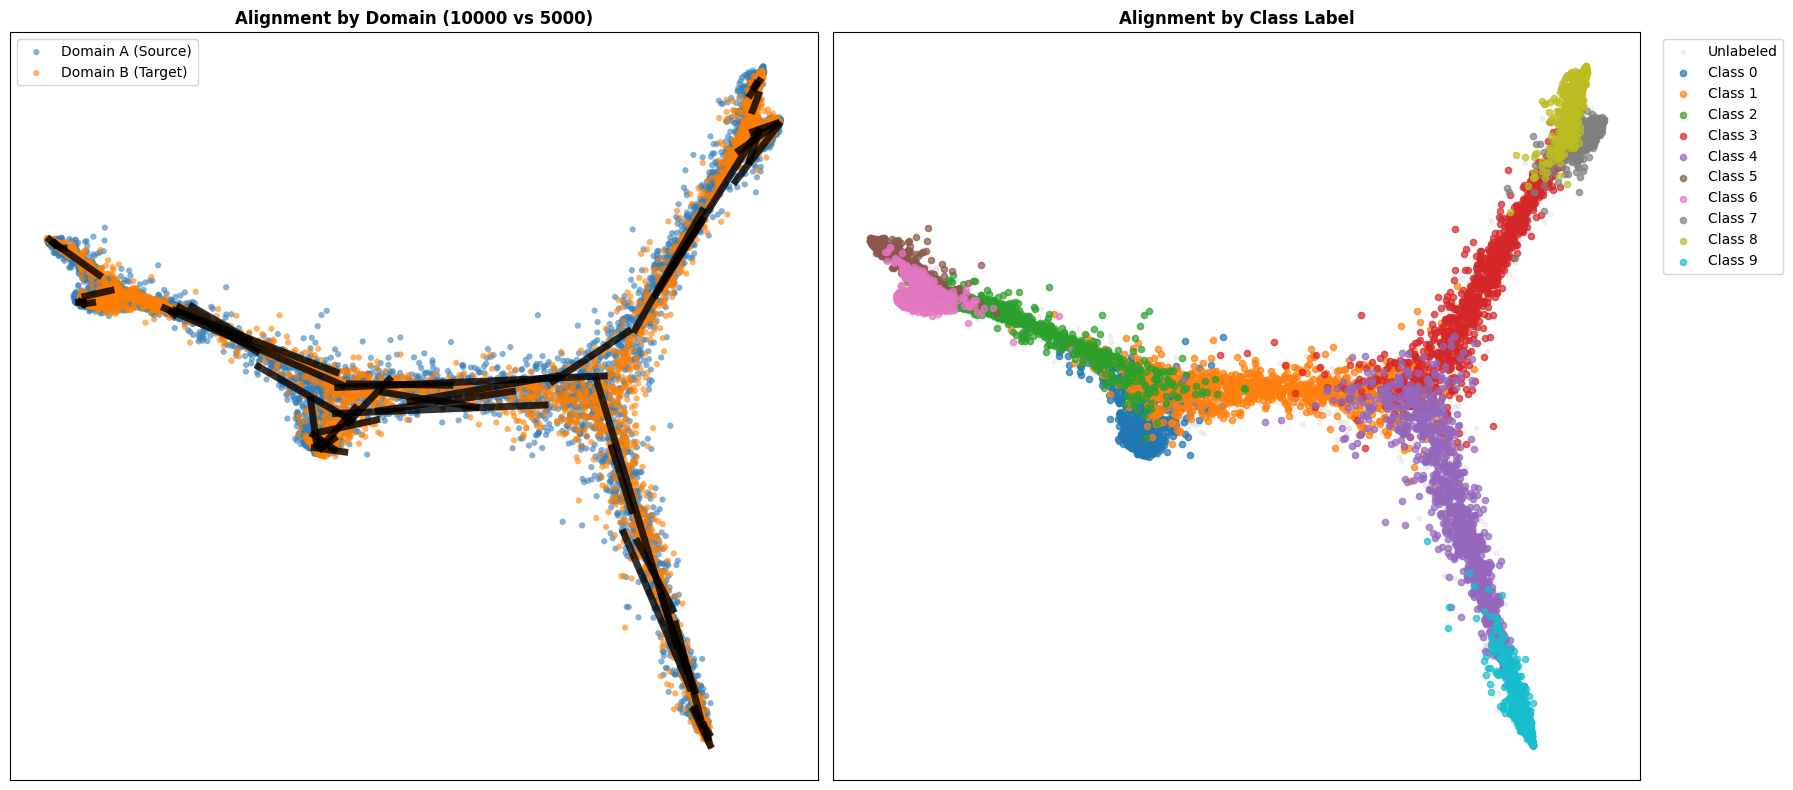

Label Accuracy (Known Labels): 0.9025
Domain Mixing (Lower is better): -0.0022


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score

# ------------------------------------
# VISUALIZATION (Robust to Uneven Sizes)
# ------------------------------------
print("\n--- Visualization ---")

# 1. SETUP & SIZE CHECKS
# ------------------------------------
# Ensure we are working with flat arrays
y_source_vis = np.array(y_source).flatten()
y_target_vis = np.array(y_target).flatten()

n_a = len(y_source_vis)
n_b = len(y_target_vis)
n_total_labels = n_a + n_b
n_total_embed = embedding.shape[0]

print(f"Data Check: Source={n_a}, Target={n_b} | Embedding shape={embedding.shape}")

# Safety Fix: If embedding doesn't match labels (e.g. stale variables), we stop to prevent weird plots
if n_total_embed != n_total_labels:
    print(f"(!) CRITICAL WARNING: Embedding has {n_total_embed} points but labels have {n_total_labels}.")
    print("    Adjusting logic to fit the SMALLER size to avoid crash.")
    min_len = min(n_total_embed, n_total_labels)
    # Truncate to safe limit for plotting purposes
    labels_combined = np.concatenate([y_source_vis, y_target_vis])[:min_len]
    embedding_vis = embedding[:min_len]
    
    # Re-calculate split point for domains
    # We assume Source is first. If Source is larger than min_len, Source gets cut.
    # Ideally, this shouldn't happen if code is run in order.
    real_n_a = min(n_a, min_len)
    real_n_b = min_len - real_n_a
else:
    labels_combined = np.concatenate([y_source_vis, y_target_vis]).astype(int)
    embedding_vis = embedding
    real_n_a = n_a
    real_n_b = n_b

# Create Domain Labels
domains_combined = np.concatenate([
    np.full(real_n_a, "Domain A (Source)"),
    np.full(real_n_b, "Domain B (Target)")
])

# 2. GENERATE PLOTS
# ------------------------------------
plt.figure(figsize=(18, 8))

# === PLOT 1: ALIGNMENT BY DOMAIN ===
ax1 = plt.subplot(1, 2, 1)

domain_colors = {"Domain A (Source)": "#377eb8", "Domain B (Target)": "#ff7f00"}
for domain, color in domain_colors.items():
    idx = (domains_combined == domain)
    if np.sum(idx) > 0:
        ax1.scatter(
            embedding_vis[idx, 0], embedding_vis[idx, 1],
            c=color, label=domain, alpha=0.6, s=20, edgecolors='none'
        )

# --- MATCHING LINES (ROBUST VERSION) ---
try:
    if 'T_true' in locals() and T_true is not None:
        T_vis = T_true
        if sparse.issparse(T_vis): T_vis = T_vis.toarray()
        
        # KEY FIX: Adjust T_true to match removed samples
        # If we have 'keep_idx' (indices of targets kept), we must slice T_true columns
        if 'keep_idx' in locals() and len(keep_idx) == real_n_b:
             if T_vis.shape[1] > len(keep_idx):
                 print(f"  Adjusting T_true columns using keep_idx...")
                 T_vis = T_vis[:, keep_idx]
        
        # Fallback: If shape still mismatches, slice strictly by dimensions
        if T_vis.shape != (real_n_a, real_n_b):
            print(f"  (!) T_true shape {T_vis.shape} != Data {(real_n_a, real_n_b)}. Slicing to fit.")
            T_vis = T_vis[:real_n_a, :real_n_b]

        # Draw Lines
        # Calculate row sums to see which Source samples actually match a REMAINING Target
        row_sums = T_vis.sum(axis=1)
        valid_sources = np.where(row_sums > 0.001)[0] # Tolerance for float
        
        # Limit to 50 lines
        if len(valid_sources) > 50:
            np.random.seed(seed)  # For reproducibility
            plot_indices = np.random.choice(valid_sources, 50, replace=False)
        else:
            plot_indices = valid_sources

        line_count = 0
        for i in plot_indices:
            j = np.argmax(T_vis[i, :]) # Best match index in the NEW target set
            
            # Final bounds check
            if i < real_n_a and j < real_n_b:
                x1, y1 = embedding_vis[i]
                x2, y2 = embedding_vis[real_n_a + j]
                ax1.plot([x1, x2], [y1, y2], c='black', alpha=0.8, linewidth=5)
                line_count += 1
                
        print(f"  Plotted {line_count} matching lines.")

except Exception as e:
    print(f"(!) Could not plot matching lines: {e}")

ax1.set_title(f"Alignment by Domain ({real_n_a} vs {real_n_b})", fontweight="bold")
ax1.legend()
ax1.set_xticks([]); ax1.set_yticks([])


# === PLOT 2: ALIGNMENT BY LABEL ===
ax2 = plt.subplot(1, 2, 2)

# Handle -1 (Unlabeled) vs Known Classes
mask_labeled = labels_combined != -1
mask_unlabeled = labels_combined == -1

# Background: Unlabeled
if np.any(mask_unlabeled):
    ax2.scatter(
        embedding_vis[mask_unlabeled, 0], embedding_vis[mask_unlabeled, 1],
        c='lightgrey', label='Unlabeled', alpha=0.3, s=10
    )

# Foreground: Labeled
if np.any(mask_labeled):
    unique_classes = np.unique(labels_combined[mask_labeled])
    cmap = plt.get_cmap("tab10")

    for i, lbl in enumerate(unique_classes):
        idx = (labels_combined == lbl)
        ax2.scatter(
            embedding_vis[idx, 0], embedding_vis[idx, 1],
            color=cmap(i % 10), label=f"Class {lbl}", alpha=0.7, s=20
        )

ax2.set_title("Alignment by Class Label", fontweight="bold")
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.set_xticks([]); ax2.set_yticks([])

plt.tight_layout()
plt.show()

# ------------------------------------
# METRICS (Safe)
# ------------------------------------
try:
    # Only calculate metrics on valid labels (-1 excluded)
    if np.any(mask_labeled):
        emb_valid = embedding_vis[mask_labeled]
        lbl_valid = labels_combined[mask_labeled]
        
        acc = accuracy_score(lbl_valid, KNeighborsClassifier(n_neighbors=5).fit(emb_valid, lbl_valid).predict(emb_valid))
        print(f"Label Accuracy (Known Labels): {acc:.4f}")
        
        sil_dom = silhouette_score(embedding_vis, domains_combined)
        print(f"Domain Mixing (Lower is better): {sil_dom:.4f}")
except Exception as e:
    print(f"Metrics error: {e}")

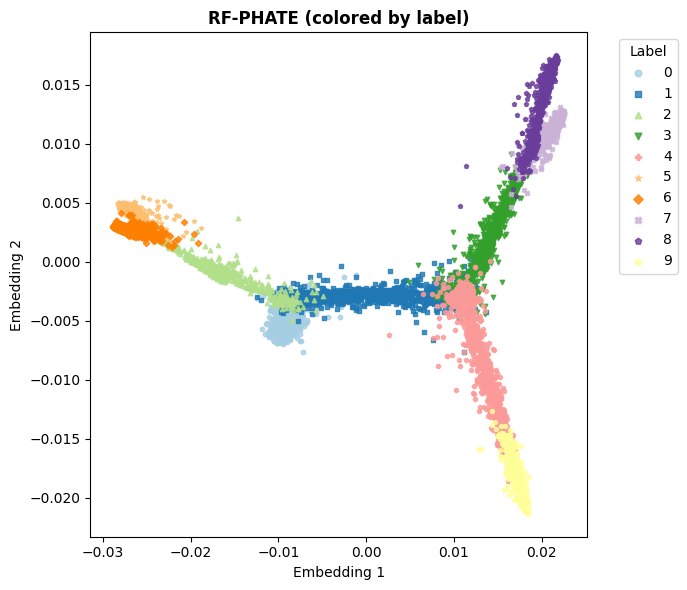

Semi-supervised mode. Forcing `non_zero_diagonal`=True and `force_symmetric`=True for consistency.
    SGD-MDS may not have converged: stress changed by 1.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.


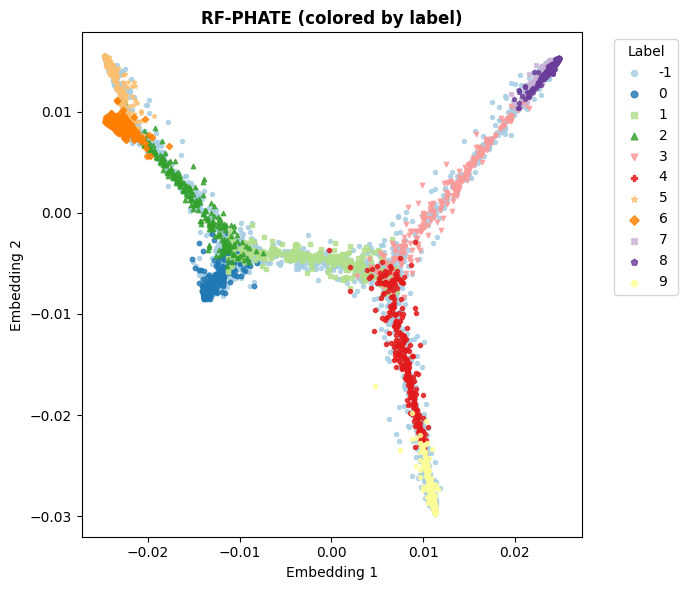

In [6]:
def plot_rfphate_labels(z, y, title="RF-PHATE (colored by label)"):
    """
    z : (n_samples, 2) RF-PHATE embedding
    y : label array (ints)
    """

    import numpy as np
    import matplotlib.pyplot as plt

    z = np.asarray(z)
    y = np.asarray(y)

    # --- Same color map & markers as your existing block ---
    cmap_10_safe = plt.get_cmap("Paired")
    markers_10 = ['o', 's', '^', 'v', 'P', '*', 'D', 'X', 'p', 'H']

    unique_labels = np.unique(y)

    plt.figure(figsize=(7, 6))

    for i, label in enumerate(unique_labels):
        idx = (y == label)
        marker_idx = label % len(markers_10)

        plt.scatter(
            z[idx, 0], z[idx, 1],
            color=cmap_10_safe(i / len(unique_labels)),
            marker=markers_10[marker_idx],
            alpha=0.8,
            s=10,
            label=str(label)
        )

    plt.title(title, fontweight="bold")
    plt.xlabel("Embedding 1")
    plt.ylabel("Embedding 2")
    plt.legend(title="Label", markerscale=1.5, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


rfp = RFPHATE(n_components=2, beta=0.5, random_state=42)
z = rfp.fit_transform(x_source, y_source)   # X: your dataset
plot_rfphate_labels(z, y_source)
# phate = PHATE(n_components=2)
# z = phate.fit_transform(x_source)   # X: your dataset
# plot_rfphate_labels(z, y_source, title="PHATE (colored by label)")

z = rfp.fit_transform(x_target, y_target)   # X: your dataset
plot_rfphate_labels(z, y_target)